# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [ ]:
%pip install --upgrade plotly

     |████████████████████████████████| 13.1MB 310kB/s 
  Found existing installation: plotly 4.4.1
    Uninstalling plotly-4.4.1:
      Successfully uninstalled plotly-4.4.1


## Import Statements

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [36]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(df_hh_income.shape)
print(df_pct_poverty.shape)
print(df_pct_completed_hs.shape)
print(df_share_race_city.shape)
print(df_fatalities.shape)

(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)
(2535, 14)


In [6]:
df_hh_income.columns

Index(['Geographic Area', 'City', 'Median Income'], dtype='object')

In [7]:
df_pct_poverty.columns

Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')

In [8]:
df_pct_completed_hs.columns

Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')

In [9]:
df_share_race_city.columns

Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')

In [10]:
df_fatalities.columns

Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')

In [27]:
# Check head of DataFrames
df_hh_income.head()

,Geographic Area,City,Median Income
0,AL,Abanda CDP,11207
1,AL,Abbeville city,25615
2,AL,Adamsville city,42575
3,AL,Addison town,37083
4,AL,Akron town,21667


In [28]:
df_pct_poverty.head()

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.8
1,AL,Abbeville city,29.1
2,AL,Adamsville city,25.5
3,AL,Addison town,30.7
4,AL,Akron town,42


In [30]:
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.2
1,AL,Abbeville city,69.1
2,AL,Adamsville city,78.9
3,AL,Addison town,81.4
4,AL,Akron town,68.6


In [31]:
df_share_race_city.head()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [32]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [33]:
df_hh_income.info(), df_pct_poverty.info(), df_pct_completed_hs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29322 entries, 0 to 29321
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29322 non-null  object
 1   City             29322 non-null  object
 2   Median Income    29271 non-null  object
dtypes: object(3)
memory usage: 687.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29329 non-null  object
 1   City             29329 non-null  object
 2   poverty_rate     29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Geographic Area       29329 non-null 

(None, None, None)

In [34]:
df_share_race_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29268 entries, 0 to 29267
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Geographic area        29268 non-null  object
 1   City                   29268 non-null  object
 2   share_white            29268 non-null  object
 3   share_black            29268 non-null  object
 4   share_native_american  29268 non-null  object
 5   share_asian            29268 non-null  object
 6   share_hispanic         29268 non-null  object
dtypes: object(7)
memory usage: 1.6+ MB


In [35]:
df_fatalities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   object 
 2   date                     2535 non-null   object 
 3   manner_of_death          2535 non-null   object 
 4   armed                    2526 non-null   object 
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   object 
 7   race                     2340 non-null   object 
 8   city                     2535 non-null   object 
 9   state                    2535 non-null   object 
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   object 
 12  flee                     2470 non-null   object 
 13  body_camera              2535 non-null   bool   
dtypes: bool(2), float64(1), 

In [11]:
df_hh_income.isna().sum()

Geographic Area     0
City                0
Median Income      51
dtype: int64

<Axes: >

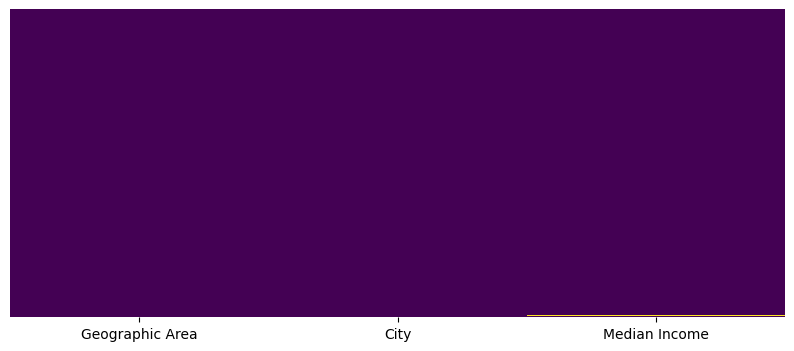

In [22]:
plt.figure(figsize=(10,4))
sns.heatmap(df_hh_income.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [13]:
df_pct_poverty.isna().sum()

Geographic Area    0
City               0
poverty_rate       0
dtype: int64

<Axes: >

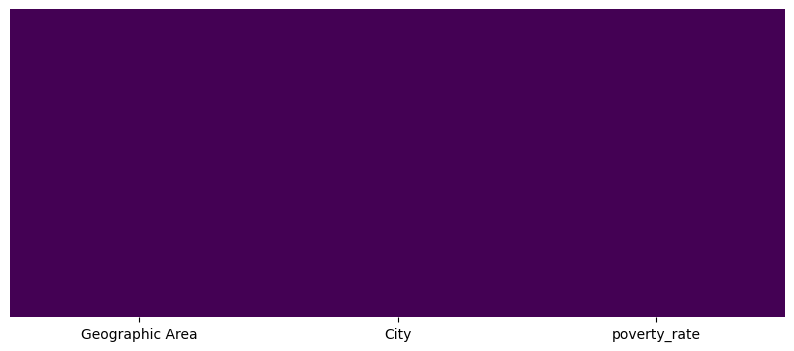

In [23]:
plt.figure(figsize=(10,4))
sns.heatmap(df_pct_poverty.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [14]:
df_pct_completed_hs.isna().sum()

Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

<Axes: >

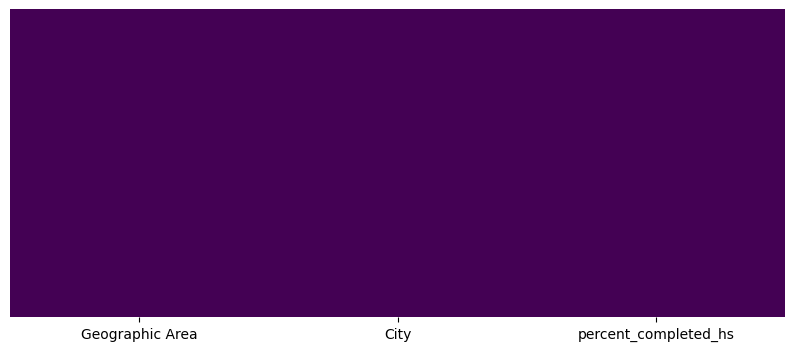

In [24]:
plt.figure(figsize=(10,4))
sns.heatmap(df_pct_completed_hs.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [15]:
df_share_race_city.isna().sum()

Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

<Axes: >

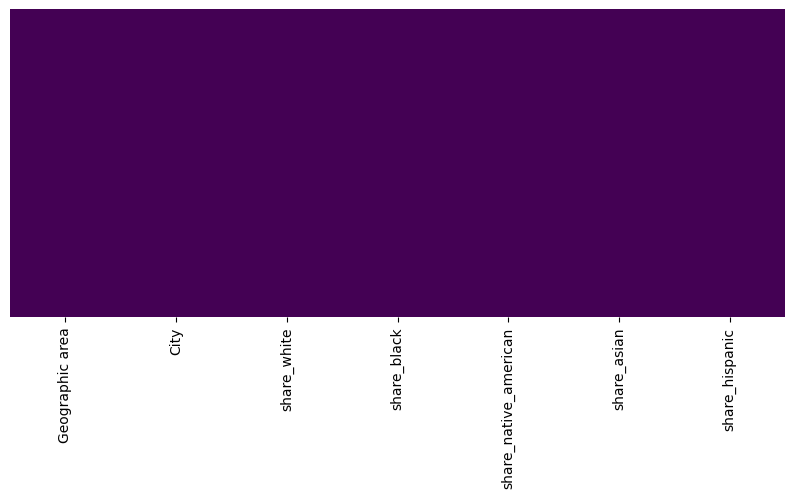

In [25]:
plt.figure(figsize=(10,4))
sns.heatmap(df_share_race_city.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [16]:
df_fatalities.isna().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

<Axes: >

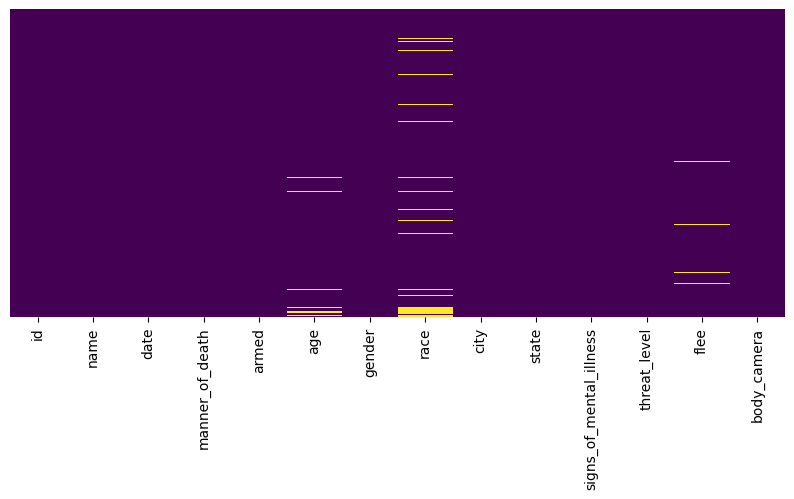

In [26]:
plt.figure(figsize=(10,4))
sns.heatmap(df_fatalities.isnull(), yticklabels=False, cbar=False, cmap='viridis')

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [17]:
df_hh_income.duplicated().sum()

np.int64(0)

In [18]:
df_pct_poverty.duplicated().sum()

np.int64(0)

In [19]:
df_pct_completed_hs.duplicated().sum()

np.int64(0)

In [20]:
df_share_race_city.duplicated().sum()

np.int64(0)

In [21]:
df_fatalities.duplicated().sum()

np.int64(0)

In [37]:
df_hh_income['Median Income'] = df_hh_income['Median Income'].replace(np.nan, 0)

In [38]:
df_fatalities['race'] = df_fatalities['race'].fillna('NA')
df_fatalities['flee'] = df_fatalities['flee'].fillna('NA')
df_fatalities['age'] = df_fatalities['age'].fillna(df_fatalities['age'].median())
df_fatalities

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2530,2822,Rodney E. Jacobs,28/07/17,shot,gun,31.00,M,NA,Kansas City,MO,False,attack,Not fleeing,False
2531,2813,TK TK,28/07/17,shot,vehicle,34.00,M,NA,Albuquerque,NM,False,attack,Car,False
2532,2818,Dennis W. Robinson,29/07/17,shot,gun,48.00,M,NA,Melba,ID,False,attack,Car,False
2533,2817,Isaiah Tucker,31/07/17,shot,vehicle,28.00,M,B,Oshkosh,WI,False,attack,Car,True


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [41]:
df_pct_poverty['Geographic Area'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'], dtype=object)

In [44]:
df_pct_poverty.poverty_rate.replace('-', np.nan, regex=True, inplace=True)
df_pct_poverty.poverty_rate = df_pct_poverty.poverty_rate.astype(float)

In [45]:
poverty = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False)
poverty

Geographic Area
MS   26.88
AZ   25.67
GA   23.78
NM   23.08
AR   22.96
LA   22.34
SC   22.16
WV   21.13
OK   20.66
AL   20.65
MO   20.11
KY   20.08
TX   19.92
TN   19.89
AK   19.85
NC   19.75
ID   18.24
DC   18.00
MI   17.90
FL   17.57
CA   17.12
ME   16.89
OR   16.52
MT   16.51
SD   16.03
IN   15.50
WA   15.02
OH   14.85
KS   14.76
VA   14.59
IL   13.88
VT   13.79
MN   13.75
HI   13.40
CO   13.36
NE   12.98
WI   12.86
NH   12.66
DE   12.56
PA   12.52
NV   12.47
IA   12.29
ND   12.16
UT   11.98
NY   11.67
RI   10.37
MD   10.31
WY    9.89
MA    9.59
CT    9.14
NJ    8.19
Name: poverty_rate, dtype: float64

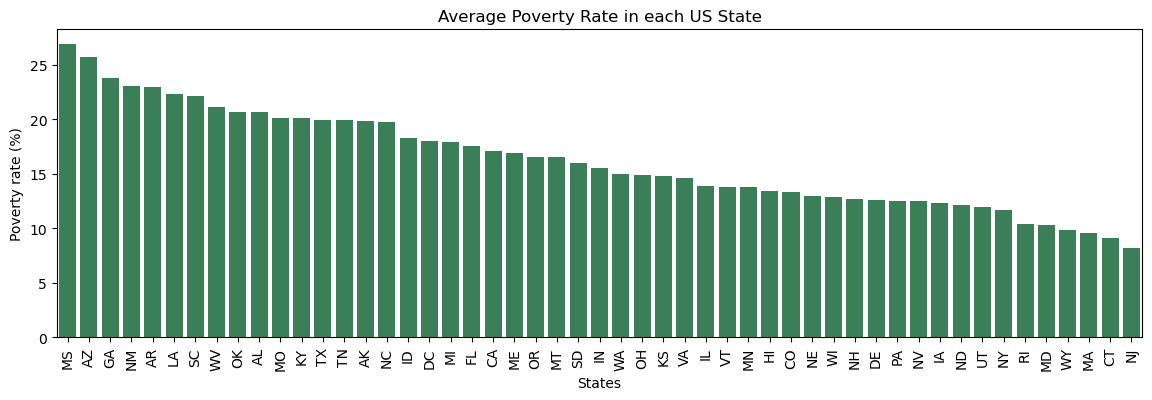

In [49]:
plt.figure(figsize=(14, 4))
sns.barplot(x=poverty.index, y=poverty.values, color='seagreen')

plt.xticks(rotation=90)
plt.xlabel('States')
plt.ylabel('Poverty rate (%)')
plt.title('Average Poverty Rate in each US State')
plt.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [50]:
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.2
1,AL,Abbeville city,69.1
2,AL,Adamsville city,78.9
3,AL,Addison town,81.4
4,AL,Akron town,68.6


In [51]:
df_pct_completed_hs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Geographic Area       29329 non-null  object
 1   City                  29329 non-null  object
 2   percent_completed_hs  29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB


In [52]:
df_pct_completed_hs.percent_completed_hs.replace('-', np.nan, regex=True, inplace=True)
df_pct_completed_hs.percent_completed_hs = df_pct_completed_hs.percent_completed_hs.astype(float)

/var/folders/74/hnhml7810vndpqrx3ztdm9kh0000gn/T/ipykernel_88962/4191562210.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pct_completed_hs.percent_completed_hs.replace('-', np.nan, regex=True, inplace=True)


In [54]:
graduation = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values(ascending=False)
graduation

Geographic Area
MA   92.40
WY   92.10
HI   91.67
UT   91.62
CT   91.59
ME   91.43
NJ   90.85
NH   90.71
NY   90.61
MT   90.49
WI   90.26
IA   90.11
CO   90.11
NE   89.99
VT   89.98
MN   89.47
DC   89.30
MI   89.21
PA   89.02
RI   88.82
DE   88.52
IL   88.48
MD   88.42
OH   88.34
OR   88.30
KS   88.23
WA   88.20
ND   87.82
SD   87.75
NV   87.72
IN   86.32
FL   85.74
ID   85.17
VA   84.88
AK   84.63
MO   83.52
NC   83.25
OK   82.91
KY   82.37
WV   82.35
CA   81.96
TN   81.63
NM   80.98
SC   80.85
AZ   80.47
AL   80.30
AR   79.95
LA   79.29
GA   79.01
MS   78.47
TX   75.69
Name: percent_completed_hs, dtype: float64

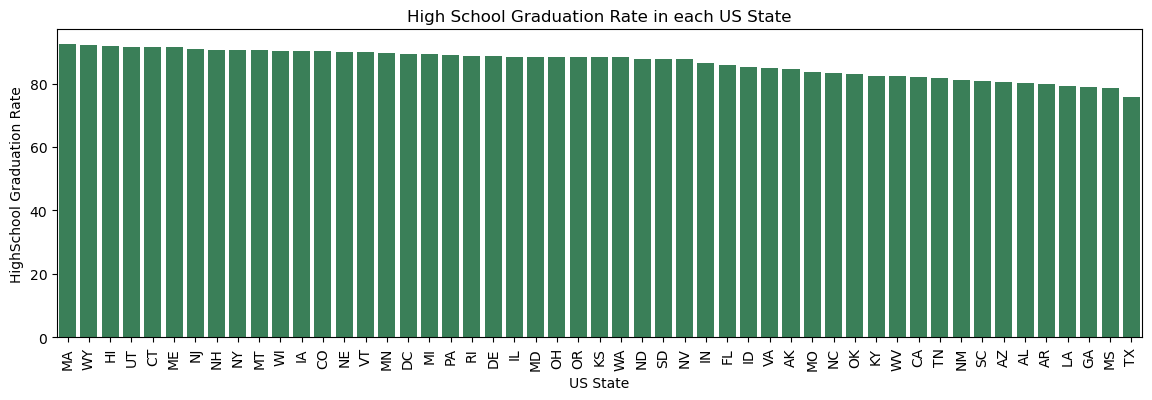

In [58]:
plt.figure(figsize=(14, 4))
sns.barplot(x=graduation.index, y=graduation.values, color='seagreen')

plt.xticks(rotation=90)
plt.xlabel('US State')
plt.ylabel('HighSchool Graduation Rate')
plt.title('High School Graduation Rate in each US State')
plt.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [59]:
graduation_rate = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean()
graduation_rate

Geographic Area
AK   84.63
AL   80.30
AR   79.95
AZ   80.47
CA   81.96
CO   90.11
CT   91.59
DC   89.30
DE   88.52
FL   85.74
GA   79.01
HI   91.67
IA   90.11
ID   85.17
IL   88.48
IN   86.32
KS   88.23
KY   82.37
LA   79.29
MA   92.40
MD   88.42
ME   91.43
MI   89.21
MN   89.47
MO   83.52
MS   78.47
MT   90.49
NC   83.25
ND   87.82
NE   89.99
NH   90.71
NJ   90.85
NM   80.98
NV   87.72
NY   90.61
OH   88.34
OK   82.91
OR   88.30
PA   89.02
RI   88.82
SC   80.85
SD   87.75
TN   81.63
TX   75.69
UT   91.62
VA   84.88
VT   89.98
WA   88.20
WI   90.26
WV   82.35
WY   92.10
Name: percent_completed_hs, dtype: float64

In [60]:
poverty_rate = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean()
poverty_rate

Geographic Area
AK   19.85
AL   20.65
AR   22.96
AZ   25.67
CA   17.12
CO   13.36
CT    9.14
DC   18.00
DE   12.56
FL   17.57
GA   23.78
HI   13.40
IA   12.29
ID   18.24
IL   13.88
IN   15.50
KS   14.76
KY   20.08
LA   22.34
MA    9.59
MD   10.31
ME   16.89
MI   17.90
MN   13.75
MO   20.11
MS   26.88
MT   16.51
NC   19.75
ND   12.16
NE   12.98
NH   12.66
NJ    8.19
NM   23.08
NV   12.47
NY   11.67
OH   14.85
OK   20.66
OR   16.52
PA   12.52
RI   10.37
SC   22.16
SD   16.03
TN   19.89
TX   19.92
UT   11.98
VA   14.59
VT   13.79
WA   15.02
WI   12.86
WV   21.13
WY    9.89
Name: poverty_rate, dtype: float64

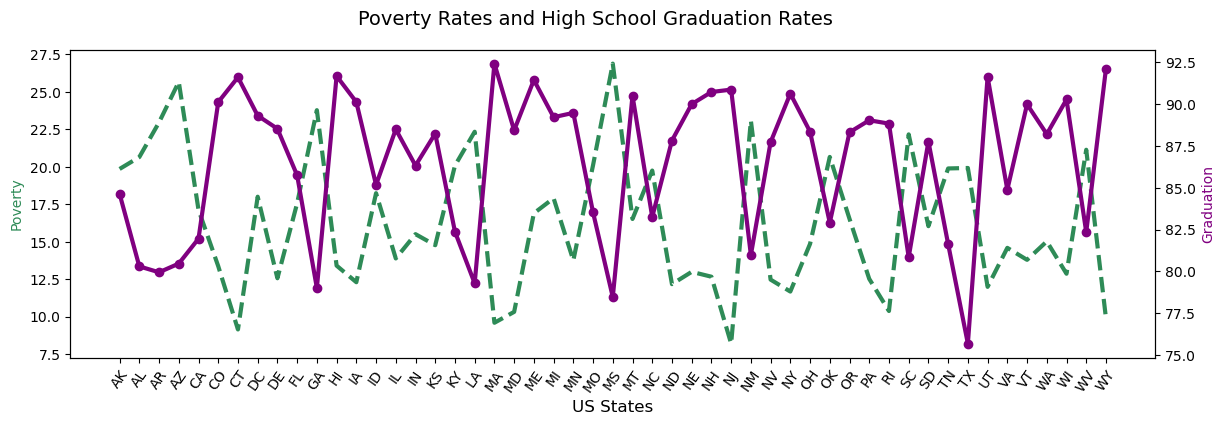

In [73]:
plt.figure(figsize=(14,4))
plt.suptitle('Poverty Rates and High School Graduation Rates', fontsize=14)
plt.xlabel('US States', fontsize=12)
plt.xticks(fontsize=10, rotation=55)

ax1 = plt.gca()
ax2 = ax1.twinx()
 
ax1.set_ylabel('Poverty', color='seagreen') # can use a HEX code
ax2.set_ylabel('Graduation', color='purple') # or a named colour
 
ax1.plot(poverty_rate.index, poverty_rate, color='seagreen', linewidth=3, linestyle='--')
ax2.plot(graduation_rate.index, graduation_rate, color='purple', linewidth=3, marker='o')

plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

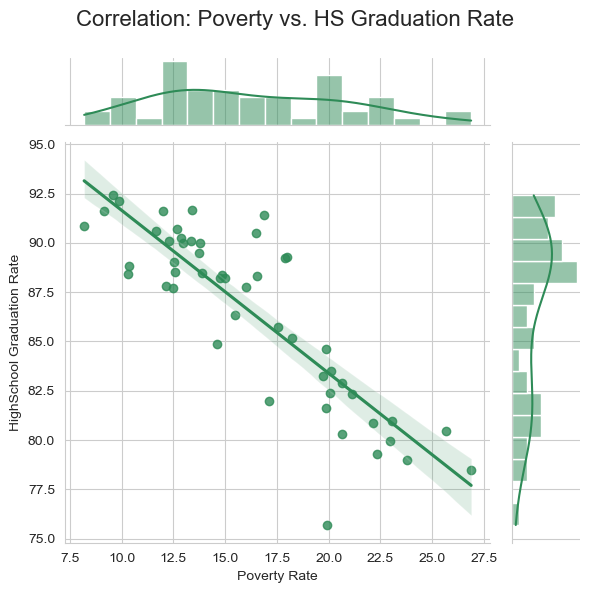

In [85]:
#combine  two series in single dataframe
merged_df = pd.DataFrame({
    'Poverty Rate':poverty_rate,
    'HighSchool Graduation Rate':graduation_rate
})

sns.set_style('whitegrid')
ax = sns.jointplot(merged_df, x = 'Poverty Rate', y = 'HighSchool Graduation Rate', color='seagreen', kind='reg', marginal_kws=dict(bins=15, fill=True))

plt.suptitle('Correlation: Poverty vs. HS Graduation Rate', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top = 0.9)

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

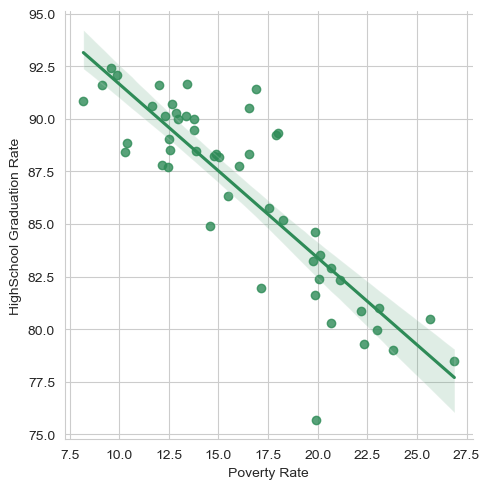

In [90]:
sns.lmplot(merged_df, x='Poverty Rate', y='HighSchool Graduation Rate', line_kws={"color": "seagreen"}, scatter_kws={"color": "seagreen"})
plt.show()

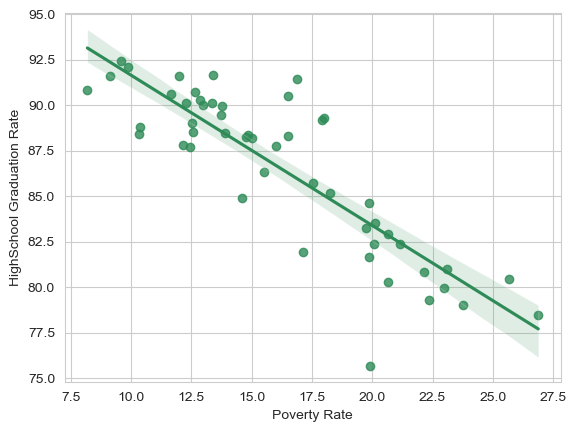

In [91]:
sns.regplot(merged_df, x='Poverty Rate', y='HighSchool Graduation Rate', line_kws={"color": "seagreen"}, scatter_kws={"color": "seagreen"})
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [93]:
df_share_race_city[['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']] = df_share_race_city[['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']].apply(pd.to_numeric, errors='coerce')

In [94]:
racial_data = df_share_race_city.groupby('Geographic area').agg({'share_white': 'mean', 'share_black': 'mean', 'share_native_american': 'mean', 'share_asian': 'mean', 'share_hispanic': 'mean'})
racial_data.head()

,share_white,share_black,share_native_american,share_asian,share_hispanic
Geographic area,,,,,
AK,45.65,0.57,45.86,1.39,2.15
AL,72.51,23.32,0.66,0.48,2.98
AR,78.45,16.30,0.76,0.48,4.27
AZ,59.93,0.95,28.59,0.73,20.14
CA,71.87,2.69,1.72,5.57,29.65


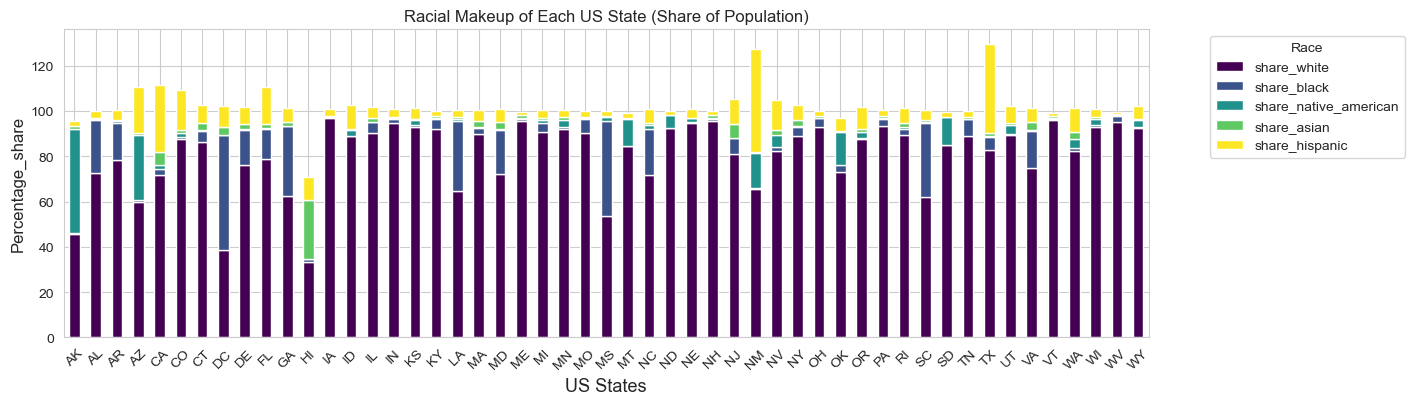

In [97]:
racial_data.plot(kind='bar', stacked=True, figsize=(14,4), colormap='viridis')

plt.title('Racial Makeup of Each US State (Share of Population)',fontsize = 12)
plt.xlabel('US States',fontsize = 13)
plt.ylabel('Percentage_share',fontsize = 12)
plt.xticks(rotation = 45)
plt.legend(title = 'Race',bbox_to_anchor = (1.05,1),loc = 'upper left')

plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [98]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [102]:
race_count = df_fatalities['race'].value_counts()
race_count             # NA - Data Not Available

race
W     1201
B      618
H      423
NA     195
A       39
N       31
O       28
Name: count, dtype: int64

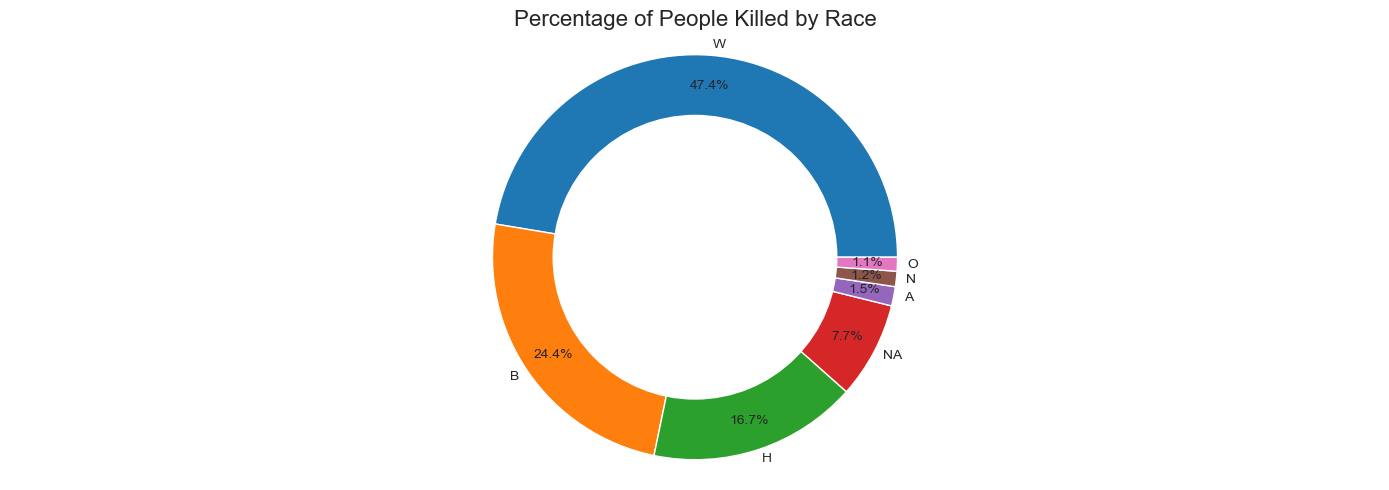

In [115]:
plt.figure(figsize=(14,5))
plt.pie(race_count.values, labels=race_count.index, autopct='%1.1f%%', labeldistance=1.05, pctdistance=0.85)

#for donate effect
centre_circle = plt.Circle((0,0),0.70,fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')
plt.title('Percentage of People Killed by Race',fontsize = 16)
plt.tight_layout()
plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [117]:
gender_count = df_fatalities.gender.value_counts()
gender_count

gender
M    2428
F     107
Name: count, dtype: int64

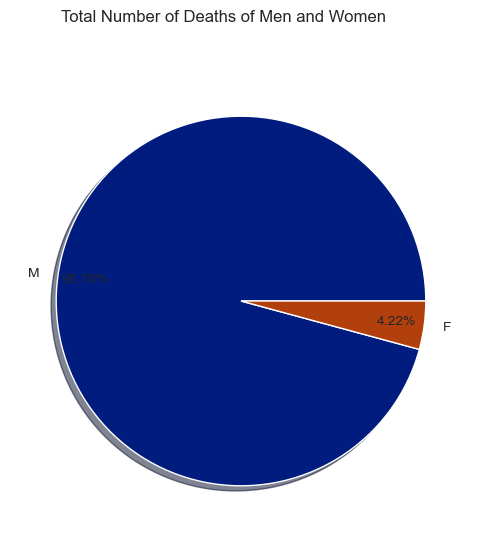

In [124]:
plt.figure(figsize=(14,6))
plt.suptitle('Total Number of Deaths of Men and Women')
colors = sns.color_palette('dark')
plt.pie(gender_count, labels=gender_count.index, colors=colors, autopct='%1.2f%%', shadow=True, pctdistance=0.85, labeldistance=1.1)

plt.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [125]:
df_fatalities['age'] = df_fatalities['age'].replace(np.nan, 0)
df_fatalities.age.isna().any()

np.False_

In [127]:
death_age = df_fatalities[['age', 'manner_of_death', 'gender']]
death_age

,age,manner_of_death,gender
0,53.00,shot,M
1,47.00,shot,M
2,23.00,shot and Tasered,M
3,32.00,shot,M
4,39.00,shot,M
...,...,...,...
2530,31.00,shot,M
2531,34.00,shot,M
2532,48.00,shot,M
2533,28.00,shot,M


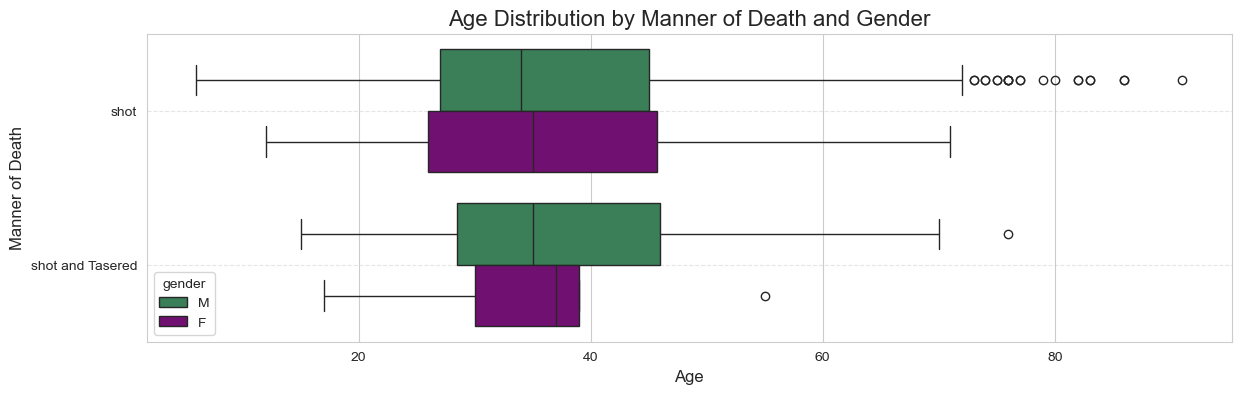

In [138]:
plt.figure(figsize=(14,4))
custom_colors = ['seagreen', 'purple']
sns.boxplot(death_age, x='age', y='manner_of_death', hue='gender', palette=custom_colors)

plt.title('Age Distribution by Manner of Death and Gender', fontsize=16)
plt.xlabel('Age',fontsize = 12)
plt.ylabel('Manner of Death',fontsize = 12)
plt.grid(axis = 'y',linestyle = '--',alpha = 0.5)

plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [142]:
weapon_count = df_fatalities['armed'].value_counts()
weapon_count

armed
gun             1398
knife            373
vehicle          177
unarmed          171
undetermined     117
                ... 
hand torch         1
garden tool        1
pole               1
pick-axe           1
pen                1
Name: count, Length: 68, dtype: int64

In [141]:
df_fatalities['armed'].unique()

array(['gun', 'unarmed', 'toy weapon', 'nail gun', 'knife', 'vehicle',
       'shovel', 'hammer', 'hatchet', 'undetermined', 'sword', 'machete',
       'box cutter', 'metal object', 'screwdriver', 'lawn mower blade',
       'flagpole', 'guns and explosives', 'cordless drill', 'crossbow',
       'metal pole', 'Taser', 'metal pipe', 'metal hand tool',
       'blunt object', 'metal stick', 'sharp object', 'meat cleaver', nan,
       'carjack', 'chain', "contractor's level", 'unknown weapon',
       'stapler', 'beer bottle', 'bean-bag gun',
       'baseball bat and fireplace poker', 'straight edge razor',
       'gun and knife', 'ax', 'brick', 'baseball bat', 'hand torch',
       'chain saw', 'garden tool', 'scissors', 'pole', 'pick-axe',
       'flashlight', 'baton', 'spear', 'pitchfork', 'hatchet and gun',
       'rock', 'piece of wood', 'bayonet', 'pipe', 'glass shard',
       'motorcycle', 'metal rake', 'crowbar', 'oar', 'machete and gun',
       'tire iron', 'air conditioner', 'pole a

/var/folders/74/hnhml7810vndpqrx3ztdm9kh0000gn/T/ipykernel_88962/2606390096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = weapon_count.index, y = weapon_count.values, palette='viridis')


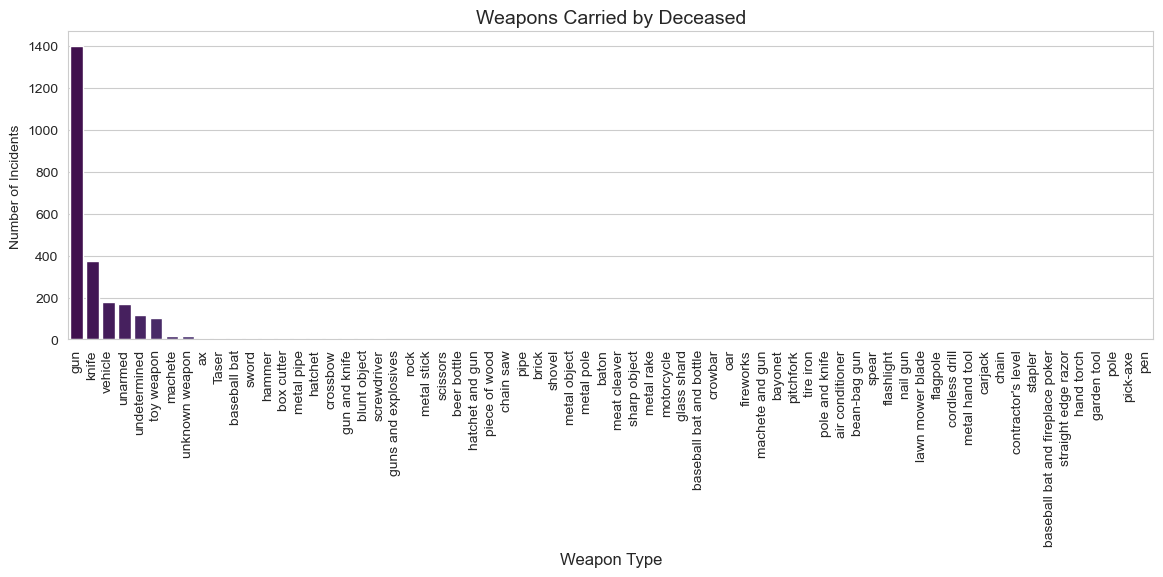

In [151]:
plt.figure(figsize=(14,4))
sns.barplot(x = weapon_count.index, y = weapon_count.values, palette='viridis')

plt.title('Weapons Carried by Deceased',fontsize = 14)
plt.xlabel('Weapon Type',fontsize = 12)
plt.ylabel('Number of Incidents',fontsize = 10)
plt.xticks(rotation = 90)

plt.show()

/var/folders/74/hnhml7810vndpqrx3ztdm9kh0000gn/T/ipykernel_88962/1520811774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = weapon_count[:20].index, y = weapon_count[:20].values, palette='viridis')


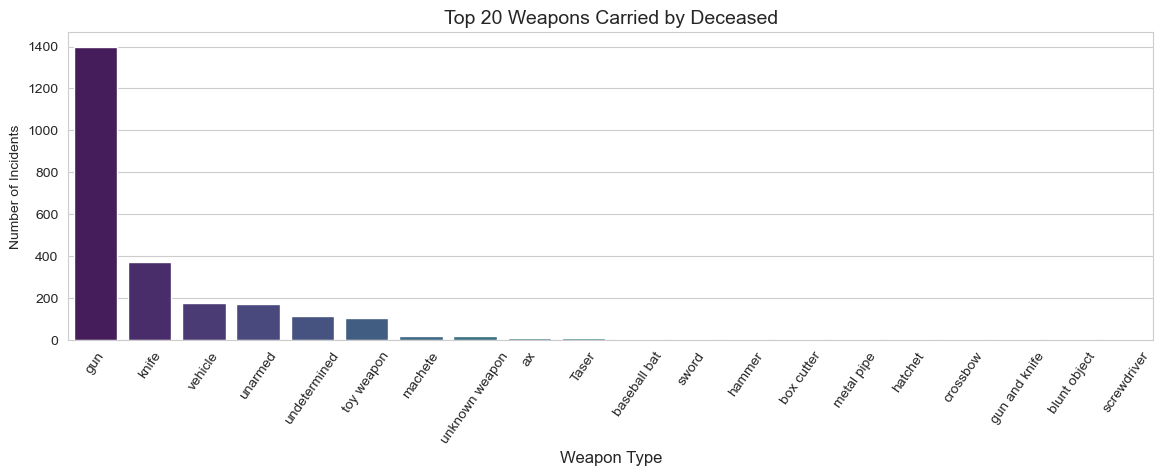

In [152]:
# Showing only top 20
plt.figure(figsize=(14,4))
sns.barplot(x = weapon_count[:20].index, y = weapon_count[:20].values, palette='viridis')

plt.title('Top 20 Weapons Carried by Deceased',fontsize = 14)
plt.xlabel('Weapon Type',fontsize = 12)
plt.ylabel('Number of Incidents',fontsize = 10)
plt.xticks(rotation = 55)

plt.show()

In [155]:
# Guns vs. Unarmed
gun_count = df_fatalities[df_fatalities['armed'] =='gun'].shape[0]
unarmed_count = df_fatalities[df_fatalities['armed'] =='unarmed'].shape[0]
other_count = df_fatalities.shape[0] - (gun_count + unarmed_count)

In [156]:
comparison_labels = ['Guns', 'Other Weapons', 'Unarmed']
comparison_values = [gun_count, other_count, unarmed_count]

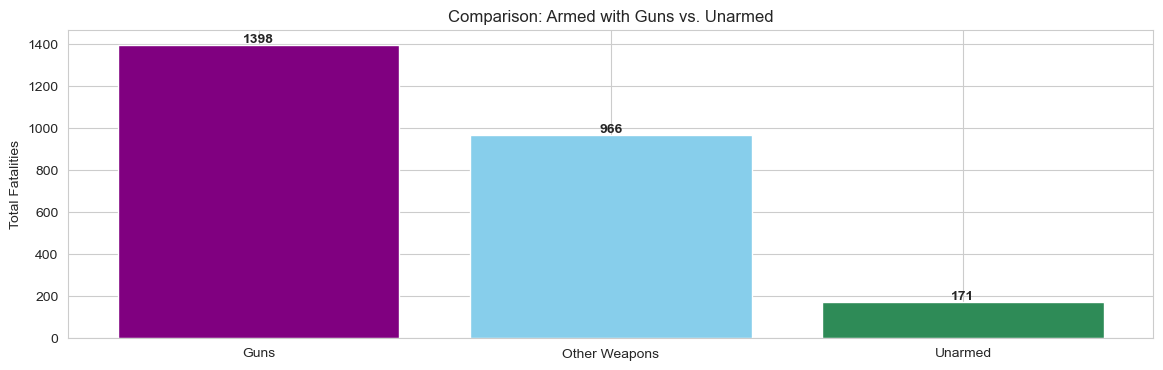

In [160]:
plt.figure(figsize=(14,4))
plt.bar(comparison_labels,comparison_values, color = ['purple', 'skyblue', 'seagreen'])

#for displaying number
for i ,val in enumerate(comparison_values):
    plt.text(i,val + 12,str(val),ha = 'center',fontweight = 'bold')

plt.title('Comparison: Armed with Guns vs. Unarmed',fontsize = 12)
plt.ylabel('Total Fatalities')

plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [169]:
killed_under_25 = df_fatalities[df_fatalities['age'] < 25]
junior = killed_under_25.id.count()

killed_over_25 = df_fatalities[df_fatalities['age'] > 25]
senior = killed_over_25.id.count()

print(f"{round((junior/senior) * 100)}% of people killed were under 25 years old.")


23% of people killed were under 25 years old.


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

<Axes: xlabel='age', ylabel='Count'>

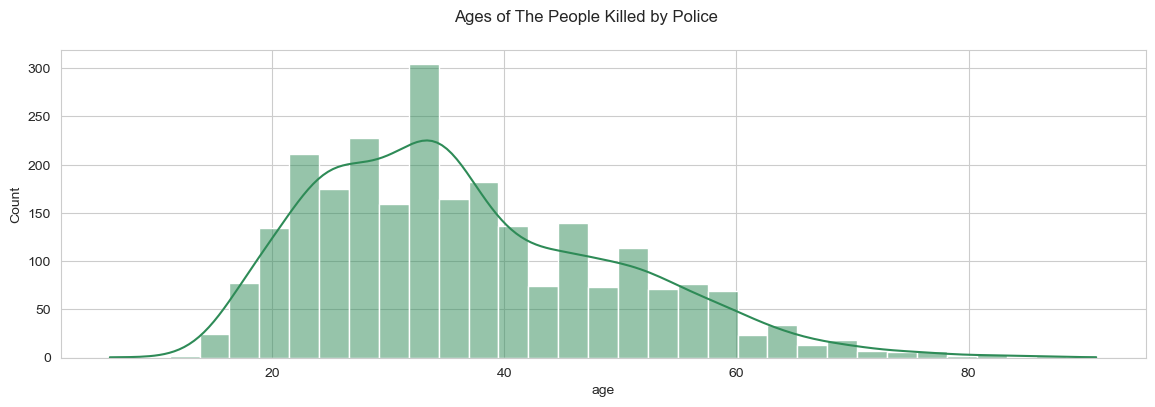

In [171]:
plt.figure(figsize=(14,4))
plt.suptitle('Ages of The People Killed by Police')
sns.histplot(df_fatalities, x='age', kde=True, color='seagreen')

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

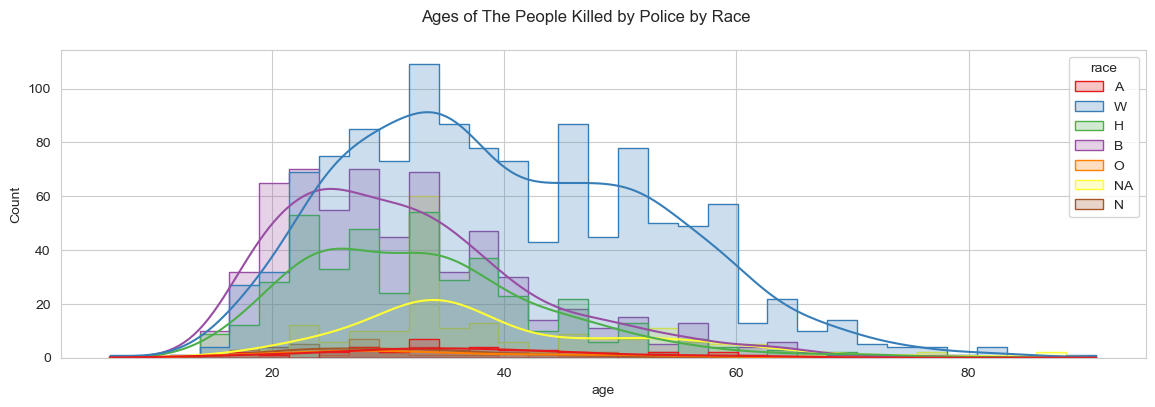

In [174]:
plt.figure(figsize=(14,4))
plt.suptitle('Ages of The People Killed by Police by Race')
sns.histplot(data=df_fatalities, x="age", kde=True, hue='race', element='step', palette='Set1')
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [182]:
killed_by_race = df_fatalities['race'].value_counts()
killed_by_race          # NA - Data 'Not Available'

race
W     1201
B      618
H      423
NA     195
A       39
N       31
O       28
Name: count, dtype: int64

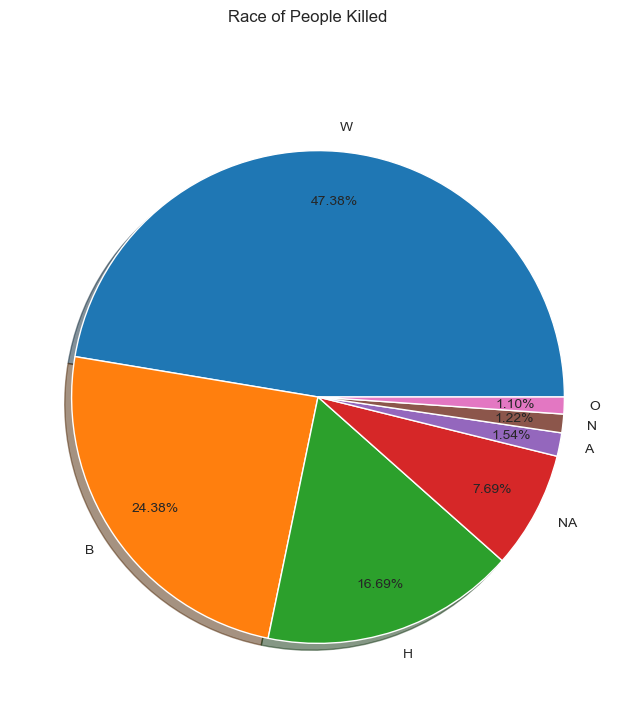

In [181]:
plt.figure(figsize=(8,8))
plt.suptitle('Race of People Killed')
plt.pie(killed_by_race, labels=killed_by_race.index, autopct='%1.2f%%', shadow=True, pctdistance=0.8, labeldistance=1.1)
plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [184]:
mental_illness = df_fatalities['signs_of_mental_illness'].value_counts()
mental_illness

signs_of_mental_illness
False    1902
True      633
Name: count, dtype: int64

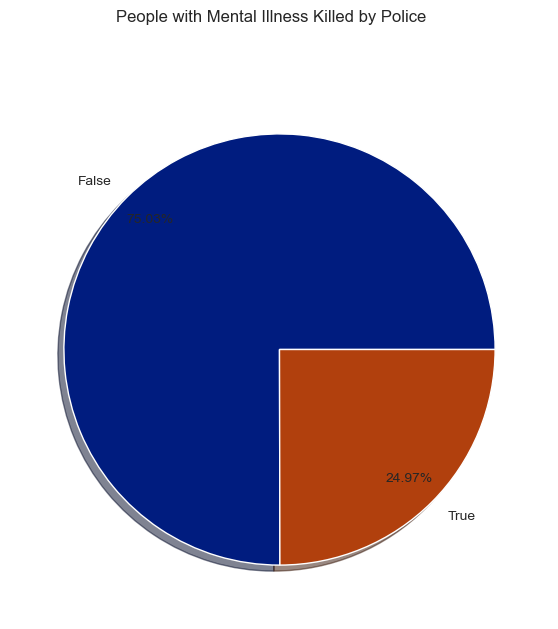

In [193]:
plt.figure(figsize=(7,7))
plt.suptitle('People with Mental Illness Killed by Police')
colors = sns.color_palette('dark')
plt.pie(mental_illness, labels=mental_illness.index, colors=colors, autopct='%1.2f%%', shadow=True, pctdistance=0.85, labeldistance=1.1)

plt.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [194]:
df_fatalities.city.unique()

array(['Shelton', 'Aloha', 'Wichita', ..., 'Glenville', 'Melba',
       'Oshkosh'], dtype=object)

In [195]:
df_fatalities.city.value_counts()

city
Los Angeles         39
Phoenix             31
Houston             27
Chicago             25
Las Vegas           21
                    ..
Columbia Heights     1
Ozark                1
Lampe                1
Seagoville           1
Oshkosh              1
Name: count, Length: 1417, dtype: int64

In [196]:
top_10_cities = df_fatalities.city.value_counts().head(10)
top_10_cities

city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Austin         18
Miami          18
St. Louis      15
Name: count, dtype: int64

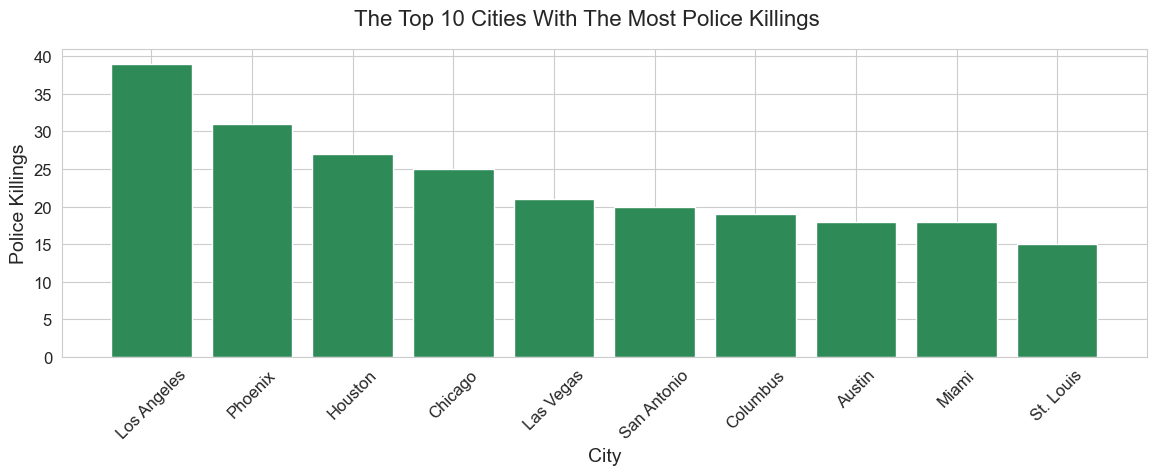

In [200]:
plt.figure(figsize=(14,4))

plt.suptitle('The Top 10 Cities With The Most Police Killings', fontsize=16)
plt.ylabel('Police Killings', fontsize=14)
plt.xlabel('City', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.bar(top_10_cities.index, top_10_cities, label=top_10_cities.index, color='seagreen')
plt.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [201]:
top_cities_by_race = df_fatalities[['city', 'race']]
top_cities_by_race

,city,race
0,Shelton,A
1,Aloha,W
2,Wichita,H
3,San Francisco,W
4,Evans,H
...,...,...
2530,Kansas City,NA
2531,Albuquerque,NA
2532,Melba,NA
2533,Oshkosh,B


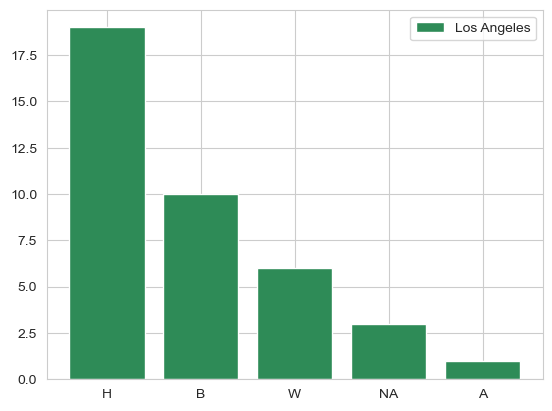

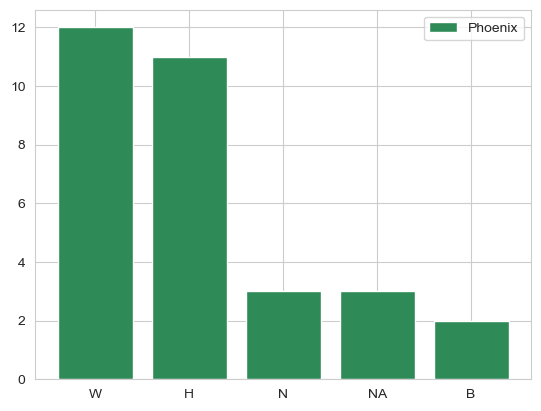

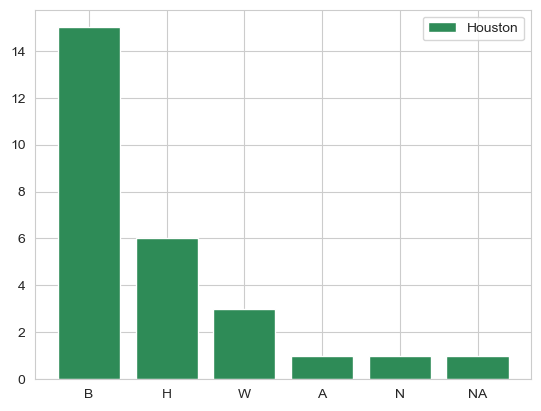

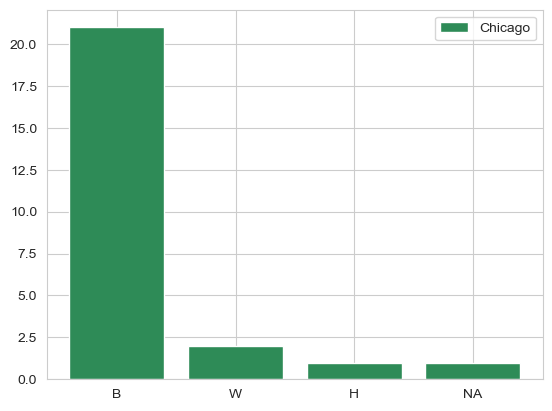

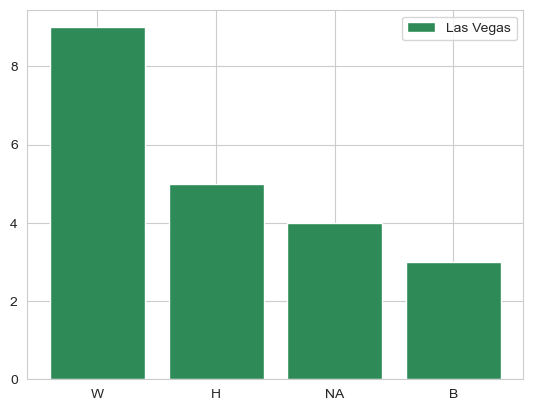

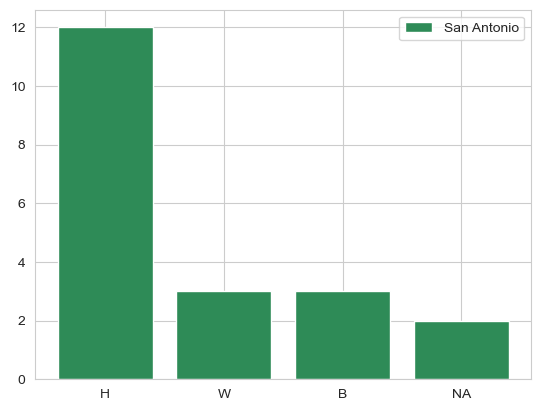

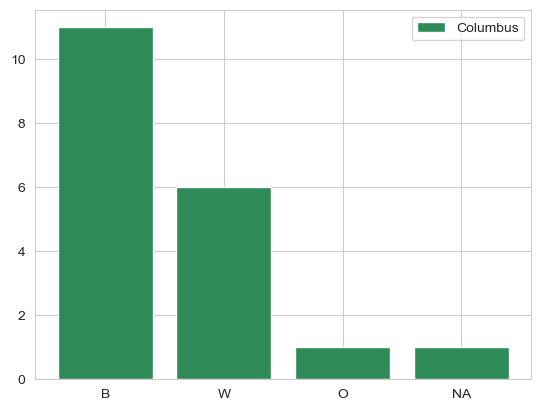

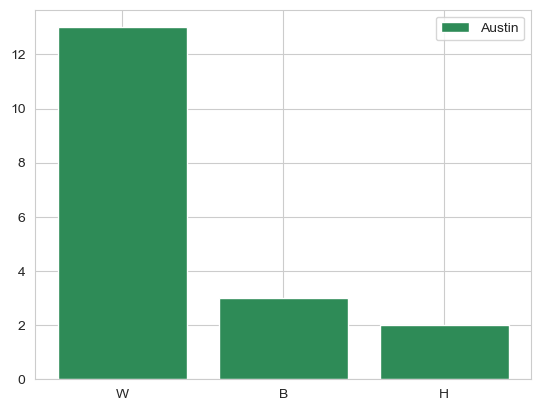

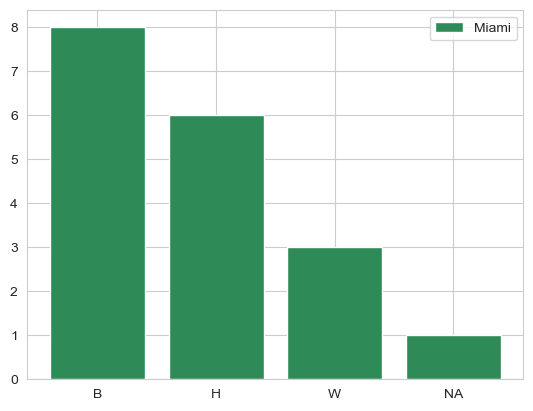

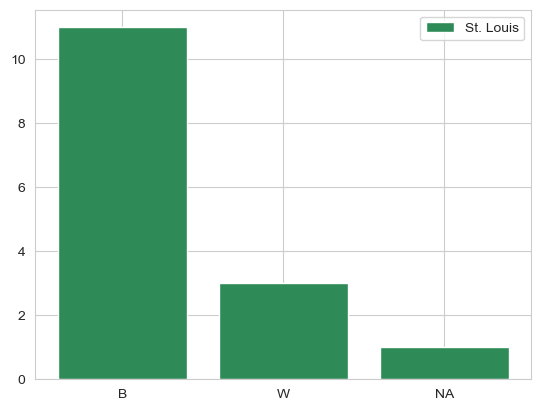

In [205]:
for c in top_10_cities.index:
    top_cities = top_cities_by_race.loc[top_cities_by_race['city'] == c]
    city = top_cities.race.value_counts()

    plt.bar(city.index, city, label=c, color='seagreen')
    plt.legend(loc='upper right')
    plt.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [ ]:
states_to_map = df_fatalities['state'].value_counts().reset_index()
states_to_map

,state,count
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79
5,OK,78
6,CO,74
7,GA,70
8,NC,69
9,MO,64


In [219]:
plt.figure(figsize=(14,4))
fig = px.choropleth(states_to_map,
                    locations='state',
                    locationmode="USA-states",
                    color = 'count',
                    color_continuous_scale='OrRd',
                    scope = 'usa',
                    title = 'Police Killings by US State')
fig.show()
plt.show()

<Figure size 1400x400 with 0 Axes>

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [225]:
history = df_fatalities.groupby('date').size()
history

date
2015-01    70
2015-02    78
2015-03    87
2015-04    88
2015-05    85
2015-06    68
2015-07    85
2015-08    86
2015-09    90
2015-10    89
2015-11    80
2015-12    85
2016-01    85
2016-02    79
2016-03    89
2016-04    75
2016-05    82
2016-06    90
2016-07    78
2016-08    79
2016-09    71
2016-10    77
2016-11    84
2016-12    74
2017-01    75
2017-02    69
2017-03    74
2017-04    70
2017-05    61
2017-06    63
2017-07    71
2017-08    18
2017-09    23
2017-10    21
2017-11    16
2017-12    20
Freq: M, dtype: int64

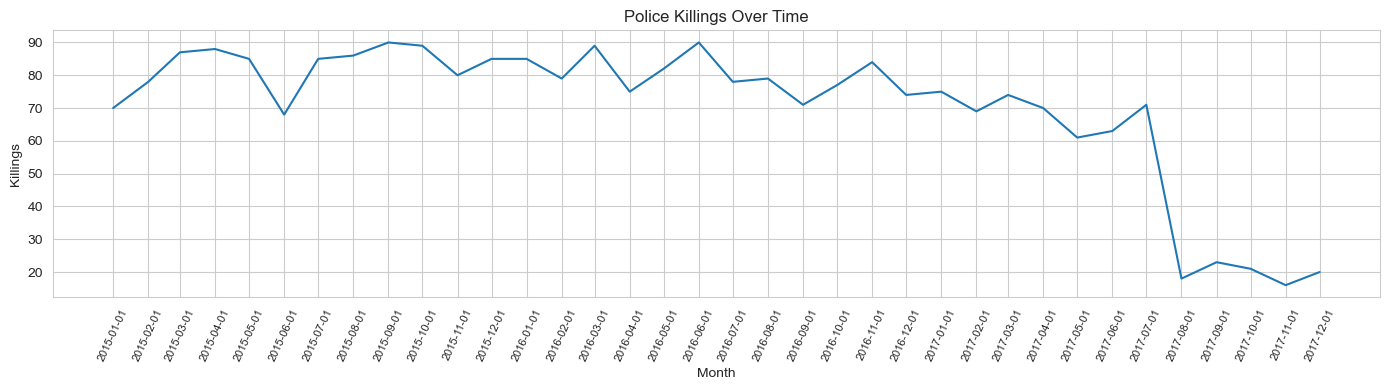

In [ ]:
history.index = history.index.to_timestamp()

plt.figure(figsize=(14,4))
plt.plot(history.index, history.values)

plt.xticks(history.index, rotation=65, fontsize=8)

plt.title('Police Killings Over Time')
plt.xlabel('Month')
plt.ylabel('Killings')

plt.tight_layout()
plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).